# Custom CNN Model Trained from Scratch for Error Classification

This notebook implements a custom Convolutional Neural Network trained from scratch to classify different types of application errors.

## 1. Import Libraries

In [40]:
# Ensure required packages are installed in the active notebook environment.
import importlib
import subprocess
import sys


def ensure_package(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"OK: {package_name} already installed")
    except ModuleNotFoundError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


ensure_package("torch")
ensure_package("torchvision")
ensure_package("scikit-learn", "sklearn")
ensure_package("seaborn")

OK: torch already installed
OK: torchvision already installed
OK: scikit-learn already installed
OK: seaborn already installed


In [41]:
import json
import random
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings("ignore")

# Set random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

PyTorch version: 2.12.0+cpu
Device: cpu


In [42]:
# Build a recursive image index using only the top-level folder as the class label.
IMAGE_EXTENSIONS = ('.png', '.jpg', '.jpeg', '.bmp', '.gif', '.webp')

def collect_class_samples(root_dir):
    root_path = Path(root_dir)
    class_names = sorted([item.name for item in root_path.iterdir() if item.is_dir()])
    samples = []
    image_counts = {}

    for class_idx, class_name in enumerate(class_names):
        class_dir = root_path / class_name
        class_images = sorted(
            path for path in class_dir.rglob('*')
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
        )
        image_counts[class_name] = len(class_images)
        samples.extend((str(path), class_idx) for path in class_images)

    return class_names, samples, image_counts


class PathImageDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None, minority_labels=None, minority_transform=None):
        self.image_paths = list(image_paths)
        self.labels = list(labels)
        self.transform = transform
        self.minority_labels = set(minority_labels or [])
        self.minority_transform = minority_transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        import PIL
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        image = PIL.Image.open(image_path).convert('RGB')

        if self.minority_transform is not None and label in self.minority_labels:
            image = self.minority_transform(image)
        elif self.transform is not None:
            image = self.transform(image)

        return image, label

## 2. Data Exploration

In [43]:
# Define data path
data_dir = r"C:\Users\Lenovo\Desktop\UB\TFM\Data"

# Recursively collect samples while keeping the label at the top-level class folder
class_names, all_samples, image_counts = collect_class_samples(data_dir)
sample_paths = [path for path, _ in all_samples]
sample_labels = np.array([label for _, label in all_samples], dtype=np.int64)
num_classes = len(class_names)

print(f"Top-level class labels: {class_names}")
print(f"Number of classes: {num_classes}")

print("\nRecursive image counts by class:")
for class_name in class_names:
    print(f"{class_name}: {image_counts[class_name]} images")

total_images = len(sample_paths)
print(f"\nTotal images: {total_images}")

summary_df = pd.DataFrame({
    'Category': class_names,
    'Image Count': [image_counts[name] for name in class_names],
    'Percentage': [f"{100 * image_counts[name] / total_images:.1f}%" for name in class_names]
})
print("\nData Summary:")
print(summary_df)

Top-level class labels: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Number of classes: 8

Recursive image counts by class:
Banner aplicación: 99 images
Cierre aplicación: 156 images
Error aplicativo: 180 images
Error funcional: 533 images
Error terminal: 404 images
Indeterminado: 18 images
Revisión circuito: 1180 images
Timeout: 194 images

Total images: 2764

Data Summary:
            Category  Image Count Percentage
0  Banner aplicación           99       3.6%
1  Cierre aplicación          156       5.6%
2   Error aplicativo          180       6.5%
3    Error funcional          533      19.3%
4     Error terminal          404      14.6%
5      Indeterminado           18       0.7%
6  Revisión circuito         1180      42.7%
7            Timeout          194       7.0%


In [44]:
# Check the class imbalance after recursive loading
count_df = pd.DataFrame({
    'Category': class_names,
    'Image Count': [image_counts[name] for name in class_names],
})
count_df['Share'] = count_df['Image Count'] / count_df['Image Count'].sum()
count_df['Imbalance vs. largest'] = count_df['Image Count'] / count_df['Image Count'].max()

print(count_df.sort_values('Image Count', ascending=False).to_string(index=False))
print(f"\nTotal images found recursively: {count_df['Image Count'].sum()}")
print(f"Largest class: {count_df.loc[count_df['Image Count'].idxmax(), 'Category']}")
print(f"Smallest class: {count_df.loc[count_df['Image Count'].idxmin(), 'Category']}")

         Category  Image Count    Share  Imbalance vs. largest
Revisión circuito         1180 0.426918               1.000000
  Error funcional          533 0.192836               0.451695
   Error terminal          404 0.146165               0.342373
          Timeout          194 0.070188               0.164407
 Error aplicativo          180 0.065123               0.152542
Cierre aplicación          156 0.056440               0.132203
Banner aplicación           99 0.035818               0.083898
    Indeterminado           18 0.006512               0.015254

Total images found recursively: 2764
Largest class: Revisión circuito
Smallest class: Indeterminado


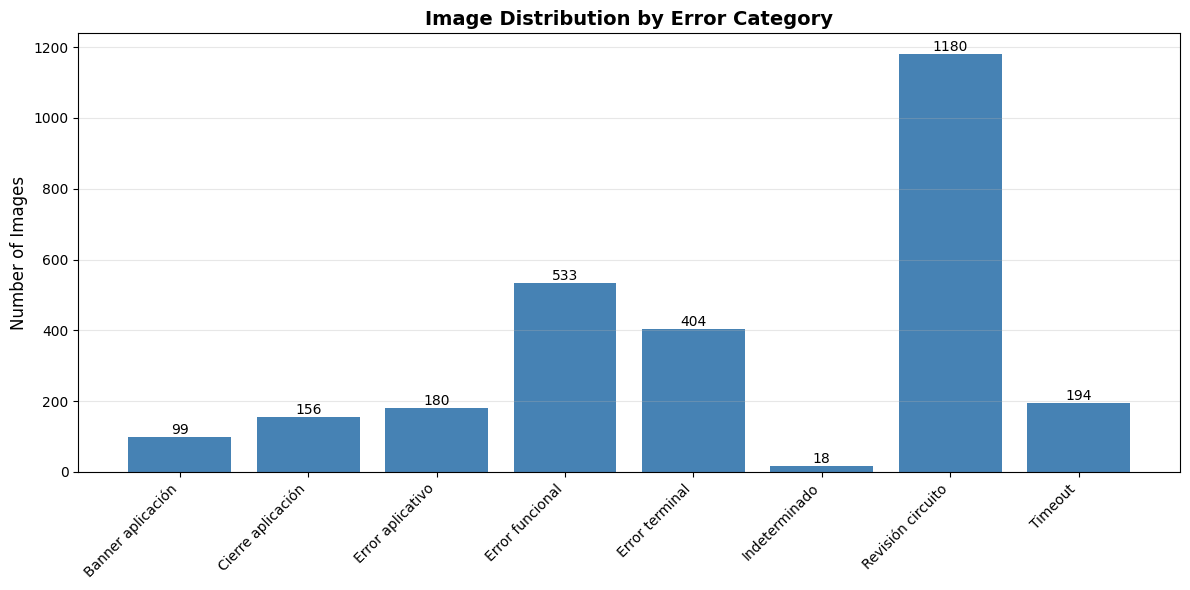


Data Summary:
            Category  Image Count Percentage
0  Banner aplicación           99       3.6%
1  Cierre aplicación          156       5.6%
2   Error aplicativo          180       6.5%
3    Error funcional          533      19.3%
4     Error terminal          404      14.6%
5      Indeterminado           18       0.7%
6  Revisión circuito         1180      42.7%
7            Timeout          194       7.0%


In [45]:
# Visualize data distribution
fig, ax = plt.subplots(figsize=(12, 6))
categories = list(image_counts.keys())
counts = list(image_counts.values())

bars = ax.bar(range(len(categories)), counts, color='steelblue')
ax.set_xticks(range(len(categories)))
ax.set_xticklabels(categories, rotation=45, ha='right')
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Image Distribution by Error Category', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Create summary dataframe
summary_df = pd.DataFrame({
    'Category': categories,
    'Image Count': counts,
    'Percentage': [f"{100*count/total_images:.1f}%" for count in counts]
})
print("\nData Summary:")
print(summary_df)

## 3. Data Preparation

In [46]:
# Define hyperparameters
IMAGE_SIZE = (224, 224)  # Standard image size for the CNN
BATCH_SIZE = 32
VALIDATION_SPLIT = 0.2
NUM_WORKERS = 0
BORDER_CROP = 120  # Crop pixels from top/bottom (mobile border effect)

print(f"Image Size: {IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Validation Split: {VALIDATION_SPLIT}")
print(f"Border Crop: {BORDER_CROP} pixels")

Image Size: (224, 224)
Batch Size: 32
Validation Split: 0.2
Border Crop: 120 pixels


In [47]:
# Build transforms with crop and resize only
def safe_mobile_border_crop(img):
    crop_margin = min(BORDER_CROP, max((img.height - 1) // 2, 0))
    return img.crop((0, crop_margin, img.width, img.height - crop_margin))

base_train_transform = transforms.Compose([
    transforms.Lambda(safe_mobile_border_crop),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

minority_train_transform = base_train_transform

val_transform = transforms.Compose([
    transforms.Lambda(safe_mobile_border_crop),
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Split recursively collected samples with stratification on top-level labels
indices = np.arange(len(sample_paths))
train_indices, val_indices = train_test_split(
    indices,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=sample_labels,
)

train_paths = [sample_paths[idx] for idx in train_indices]
train_targets = [int(sample_labels[idx]) for idx in train_indices]
val_paths = [sample_paths[idx] for idx in val_indices]
val_targets = [int(sample_labels[idx]) for idx in val_indices]

train_class_counts = Counter(train_targets)
val_class_counts = Counter(val_targets)
train_class_counts_by_name = {class_names[idx]: train_class_counts.get(idx, 0) for idx in range(num_classes)}
val_class_counts_by_name = {class_names[idx]: val_class_counts.get(idx, 0) for idx in range(num_classes)}

minority_count_threshold = int(np.median(list(train_class_counts.values())))
minority_class_indices = {
    class_idx for class_idx, count in train_class_counts.items()
    if count <= minority_count_threshold
}

train_dataset = PathImageDataset(
    train_paths,
    train_targets,
    transform=base_train_transform,
    minority_labels=minority_class_indices,
    minority_transform=minority_train_transform,
 )
val_dataset = PathImageDataset(val_paths, val_targets, transform=val_transform)

# Keep the split stratified and use class weights in the loss instead of oversampling
train_sampler = None

print(f"Image Size: {IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Validation Split: {VALIDATION_SPLIT}")
print(f"Border Crop: {BORDER_CROP} pixels")
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")
print(f"Minority count threshold (train split): {minority_count_threshold}")
print("Training transform: crop + resize only")
print(f"Minority classes: {[class_names[idx] for idx in sorted(minority_class_indices)]}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

train_counts_df = pd.DataFrame({
    'Category': class_names,
    'Train Count': [train_class_counts_by_name[name] for name in class_names],
    'Validation Count': [val_class_counts_by_name[name] for name in class_names],
})
train_counts_df['Train Share'] = train_counts_df['Train Count'] / train_counts_df['Train Count'].sum()
train_counts_df['Validation Share'] = train_counts_df['Validation Count'] / train_counts_df['Validation Count'].sum()

print("\nTrain/validation split by class:")
print(train_counts_df.to_string(index=False))

Image Size: (224, 224)
Batch Size: 32
Validation Split: 0.2
Border Crop: 120 pixels
Number of classes: 8
Class names: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Error funcional', 'Error terminal', 'Indeterminado', 'Revisión circuito', 'Timeout']
Minority count threshold (train split): 149
Training transform: crop + resize only
Minority classes: ['Banner aplicación', 'Cierre aplicación', 'Error aplicativo', 'Indeterminado']
Training samples: 2211
Validation samples: 553

Train/validation split by class:
         Category  Train Count  Validation Count  Train Share  Validation Share
Banner aplicación           79                20     0.035730          0.036166
Cierre aplicación          125                31     0.056536          0.056058
 Error aplicativo          144                36     0.065129          0.065099
  Error funcional          426               107     0.192673          0.193490
   Error terminal          323                81     0.146088          

In [48]:
# Build dataloaders without oversampling; the loss handles imbalance
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
 )

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
 )

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 70
Validation batches: 18


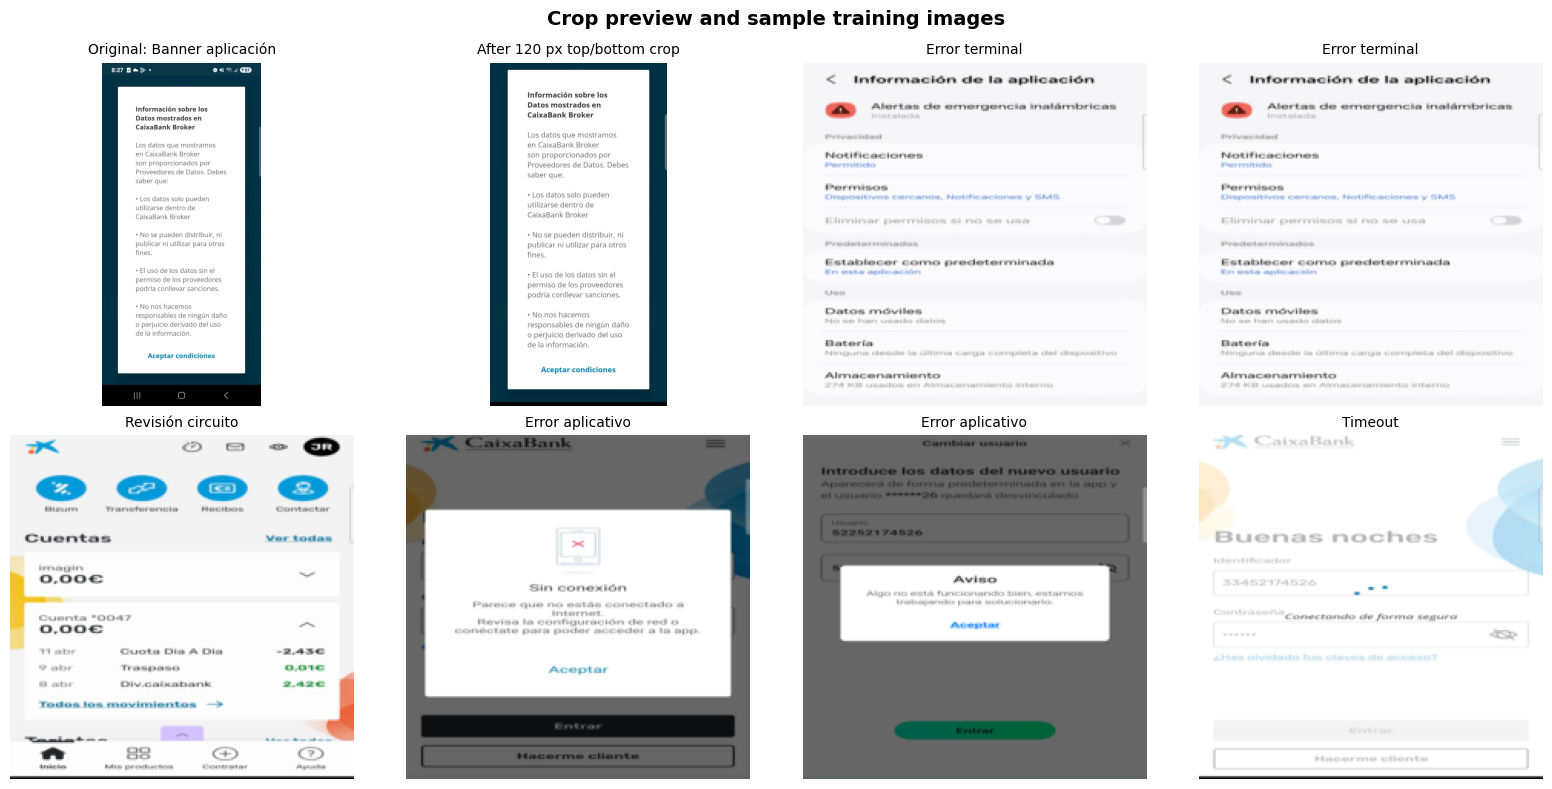

In [49]:
# Inverse normalization for visualization
inv_normalize = transforms.Compose([
    transforms.Normalize(mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
                          std=[1/0.229, 1/0.224, 1/0.225])
])

# Visualize sample images and the border crop effect
import PIL
sample_image = PIL.Image.open(sample_paths[0]).convert('RGB')
sample_label = sample_labels[0]
sample_cropped = safe_mobile_border_crop(sample_image)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

axes[0].imshow(sample_image)
axes[0].set_title(f"Original: {class_names[sample_label]}", fontsize=10)
axes[0].axis("off")

axes[1].imshow(sample_cropped)
axes[1].set_title(f"After {BORDER_CROP} px top/bottom crop", fontsize=10)
axes[1].axis("off")

images, labels = next(iter(train_loader))
for idx in range(2, min(8, len(images))):
    ax = axes[idx]
    img = inv_normalize(images[idx - 2]).permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[int(labels[idx - 2])], fontsize=10)
    ax.axis("off")

plt.suptitle("Crop preview and sample training images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Build Custom CNN Model from Scratch

In [50]:
# Define a custom CNN architecture trained from scratch
class CustomCNN(nn.Module):
    def __init__(self, num_classes=8):
        super(CustomCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 224 -> 112
            nn.Dropout(0.25),
        )
        
        # Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 112 -> 56
            nn.Dropout(0.25),
        )
        
        # Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 56 -> 28
            nn.Dropout(0.25),
        )
        
        # Block 4
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 28 -> 14
            nn.Dropout(0.25),
        )
        
        # Global Average Pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Initialize model
model = CustomCNN(num_classes=num_classes)
model = model.to(device)

print("Custom CNN Model Architecture:")
print(model)

Custom CNN Model Architecture:
CustomCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.25, inplace=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
 

In [51]:
# Model summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nAll parameters are trainable (no frozen layers)")


Total parameters: 1,273,896
Trainable parameters: 1,273,896

All parameters are trainable (no frozen layers)


In [52]:
# Configure a softened class-balanced loss and a more conservative optimizer
class_weights = torch.tensor(
    [np.sqrt(len(train_targets) / (num_classes * train_class_counts[idx])) for idx in range(num_classes)],
    dtype=torch.float32,
    device=device,
 )

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4,
 )

print("Loss and optimizer configured.")
print("Loss function: Weighted CrossEntropyLoss with label smoothing")
print("Optimizer: AdamW (lr=3e-4, weight_decay=1e-4)")
print("Class weights:")
for class_name, weight in zip(class_names, class_weights.detach().cpu().tolist()):
    print(f"  {class_name}: {weight:.4f}")

Loss and optimizer configured.
Loss function: Weighted CrossEntropyLoss with label smoothing
Optimizer: AdamW (lr=3e-4, weight_decay=1e-4)
Class weights:
  Banner aplicación: 1.8704
  Cierre aplicación: 1.4869
  Error aplicativo: 1.3854
  Error funcional: 0.8055
  Error terminal: 0.9250
  Indeterminado: 4.2924
  Revisión circuito: 0.5411
  Timeout: 1.3353


## 5. Train Model

In [53]:
# Training controls
EPOCHS = 30
PATIENCE = 7
LR_FACTOR = 0.5
LR_PATIENCE = 4
MIN_LR = 1e-7
CONFIDENCE_THRESHOLD = 0.7

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    min_lr=MIN_LR,
 )

print("Training controls configured.")
print(f"Max epochs: {EPOCHS}")
print(f"Early stopping patience: {PATIENCE}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD:.2f}")
print("The confidence threshold is only used to flag uncertain predictions.")

Training controls configured.
Max epochs: 30
Early stopping patience: 7
Confidence threshold: 0.70
The confidence threshold is only used to flag uncertain predictions.


In [54]:
# Train the model with early stopping
history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
best_val_loss = float("inf")
best_state = None
patience_counter = 0

for epoch in range(EPOCHS):
    model.train()
    train_loss_sum = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / train_total
    train_acc = train_correct / train_total

    # Validation phase
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            logits = model(images)
            loss = criterion(logits, labels)

            val_loss_sum += loss.item() * images.size(0)
            preds = torch.argmax(logits, dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    history["loss"].append(train_loss)
    history["accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1}/{EPOCHS} | "
            f"loss: {train_loss:.4f} | acc: {train_acc:.4f} | "
            f"val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f}"
        )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch + 1}.")
            break

if best_state is not None:
    model.load_state_dict(best_state)
    print("Restored best model weights.")

Epoch 1/30 | loss: 1.7583 | acc: 0.5161 | val_loss: 1.4222 | val_acc: 0.6763
Epoch 5/30 | loss: 0.7327 | acc: 0.9480 | val_loss: 0.7228 | val_acc: 0.8463
Epoch 10/30 | loss: 0.5895 | acc: 0.9742 | val_loss: 0.6725 | val_acc: 0.9458
Epoch 15/30 | loss: 0.5539 | acc: 0.9828 | val_loss: 0.5371 | val_acc: 0.9819
Epoch 20/30 | loss: 0.5147 | acc: 0.9923 | val_loss: 0.5460 | val_acc: 0.9819
Epoch 25/30 | loss: 0.4956 | acc: 0.9973 | val_loss: 0.6442 | val_acc: 0.8571
Epoch 30/30 | loss: 0.4924 | acc: 0.9968 | val_loss: 0.4959 | val_acc: 0.9928
Restored best model weights.


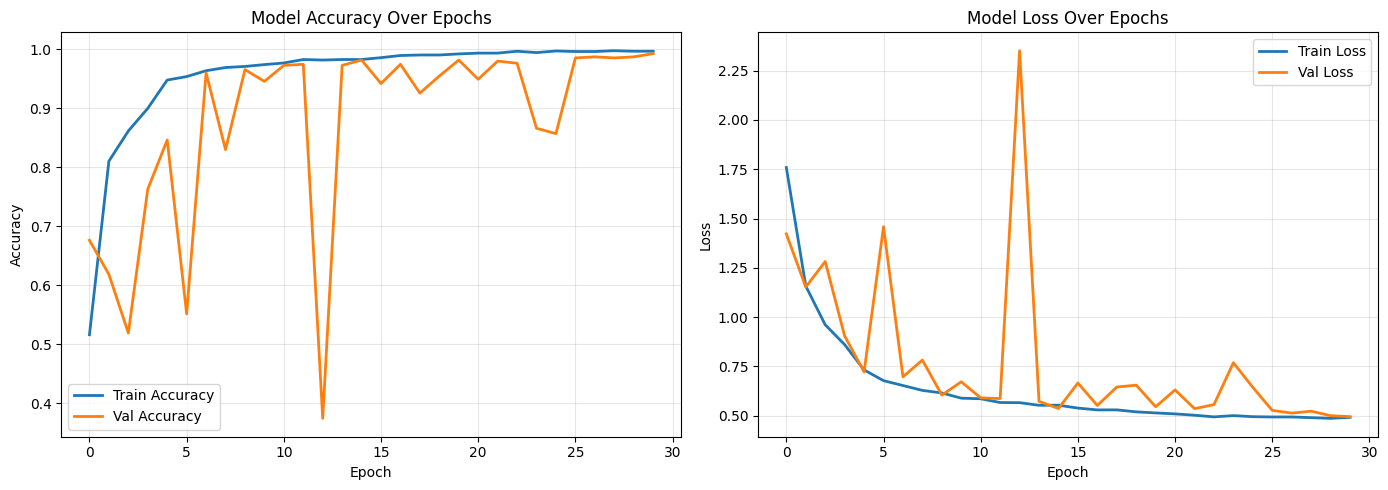


Training Summary:
Total epochs trained: 30
Best val accuracy: 0.9928
Best val loss: 0.4959
Final train accuracy: 0.9968
Final val accuracy: 0.9928


In [55]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0].plot(history['val_accuracy'], label='Val Accuracy', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history['loss'], label='Train Loss', linewidth=2)
axes[1].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Model Loss Over Epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTraining Summary:")
print(f"Total epochs trained: {len(history['loss'])}")
print(f"Best val accuracy: {max(history['val_accuracy']):.4f}")
print(f"Best val loss: {min(history['val_loss']):.4f}")
print(f"Final train accuracy: {history['accuracy'][-1]:.4f}")
print(f"Final val accuracy: {history['val_accuracy'][-1]:.4f}")

## 6. Model Evaluation

In [56]:
# Evaluate final model on validation set
model.eval()

metrics = globals().get('validation_metrics', {})
final_val_accuracy = metrics.get('accuracy', float('nan'))
final_val_balanced_accuracy = metrics.get('balanced_accuracy', float('nan'))
final_val_macro_f1 = metrics.get('macro_f1', float('nan'))

print(f"Final Validation Accuracy: {final_val_accuracy:.4f}")
print(f"Final Validation Balanced Accuracy: {final_val_balanced_accuracy:.4f}")
print(f"Final Validation Macro F1: {final_val_macro_f1:.4f}")

Final Validation Accuracy: 0.0054
Final Validation Balanced Accuracy: 0.1250
Final Validation Macro F1: 0.0013


In [57]:
# Get predictions for confusion matrix, classification report, and fairness metrics
y_pred = []
y_true = []
confidence_scores = []
val_paths = val_dataset.image_paths
failed_predictions = []
uncertain_predictions = []
path_offset = 0

model.eval()
with torch.no_grad():
    for images, labels in val_loader:
        batch_size = labels.size(0)
        batch_paths = val_paths[path_offset:path_offset + batch_size]
        path_offset += batch_size

        images = images.to(device)
        logits = model(images)
        probabilities = torch.softmax(logits, dim=1)
        max_probs, preds_tensor = torch.max(probabilities, dim=1)
        preds = preds_tensor.cpu().numpy()
        confidences = max_probs.cpu().numpy()

        y_pred.extend(preds.tolist())
        y_true.extend(labels.numpy().tolist())
        confidence_scores.extend(confidences.tolist())

        for path, true_idx, pred_idx, confidence in zip(batch_paths, labels.numpy().tolist(), preds.tolist(), confidences.tolist()):
            predicted_label = class_names[pred_idx] if confidence >= CONFIDENCE_THRESHOLD else "uncertain"
            record = {
                'path': path,
                'true_class': class_names[true_idx],
                'predicted_class': predicted_label,
                'confidence': confidence,
            }
            if confidence < CONFIDENCE_THRESHOLD:
                uncertain_predictions.append(record)
            elif true_idx != pred_idx:
                failed_predictions.append(record)

y_pred = np.array(y_pred)
y_true = np.array(y_true)
confidence_scores = np.array(confidence_scores)
failed_predictions_df = pd.DataFrame(failed_predictions)
uncertain_predictions_df = pd.DataFrame(uncertain_predictions)

validation_accuracy = accuracy_score(y_true, y_pred)
validation_balanced_accuracy = balanced_accuracy_score(y_true, y_pred)
validation_macro_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
validation_macro_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
validation_macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
validation_weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
validation_weighted_precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
validation_weighted_recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
uncertainty_rate = float(np.mean(confidence_scores < CONFIDENCE_THRESHOLD))
accepted_rate = 1.0 - uncertainty_rate

report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
per_class_metrics_df = pd.DataFrame(report_dict).T
per_class_metrics_df = per_class_metrics_df.loc[class_names, ['precision', 'recall', 'f1-score', 'support']]
per_class_metrics_df.index.name = 'class'

validation_f1_gap = float(per_class_metrics_df['f1-score'].max() - per_class_metrics_df['f1-score'].min())
validation_recall_gap = float(per_class_metrics_df['recall'].max() - per_class_metrics_df['recall'].min())
validation_worst_class_f1 = float(per_class_metrics_df['f1-score'].min())

validation_metrics = {
    'accuracy': float(validation_accuracy),
    'balanced_accuracy': float(validation_balanced_accuracy),
    'macro_precision': float(validation_macro_precision),
    'macro_recall': float(validation_macro_recall),
    'macro_f1': float(validation_macro_f1),
    'weighted_precision': float(validation_weighted_precision),
    'weighted_recall': float(validation_weighted_recall),
    'weighted_f1': float(validation_weighted_f1),
    'uncertainty_rate': float(uncertainty_rate),
    'accepted_rate': float(accepted_rate),
    'f1_gap': float(validation_f1_gap),
    'recall_gap': float(validation_recall_gap),
    'worst_class_f1': float(validation_worst_class_f1),
}

print(f"Predictions shape: {y_pred.shape}")
print(f"True labels shape: {y_true.shape}")
print(f"Validation Accuracy: {validation_accuracy:.4f}")
print(f"Validation Balanced Accuracy: {validation_balanced_accuracy:.4f}")
print(f"Validation Macro F1: {validation_macro_f1:.4f}")
print(f"Validation Weighted F1: {validation_weighted_f1:.4f}")
print(f"Validation Macro Precision: {validation_macro_precision:.4f}")
print(f"Validation Macro Recall: {validation_macro_recall:.4f}")
print(f"Uncertainty rate (< {CONFIDENCE_THRESHOLD:.2f}): {uncertainty_rate:.2%}")
print(f"Accepted predictions: {accepted_rate:.2%}")
print(f"F1 gap across classes: {validation_f1_gap:.4f}")
print(f"Recall gap across classes: {validation_recall_gap:.4f}")
print(f"Worst class F1: {validation_worst_class_f1:.4f}")
print(f"Misclassified validation samples above threshold: {len(failed_predictions_df)}")
print(f"Uncertain validation samples below threshold: {len(uncertain_predictions_df)}")

print("\nPer-class validation metrics:")
print(per_class_metrics_df.to_string())

if not failed_predictions_df.empty:
    print("\nFailed validation paths (confidence >= threshold but wrong):")
    print(failed_predictions_df[['path', 'true_class', 'predicted_class', 'confidence']].to_string(index=False))
else:
    print("\nNo misclassified validation samples with confidence above the threshold found.")

if not uncertain_predictions_df.empty:
    print("\nUncertain validation paths (confidence below threshold):")
    print(uncertain_predictions_df[['path', 'true_class', 'confidence']].to_string(index=False))
else:
    print("\nNo uncertain validation samples found.")

Predictions shape: (553,)
True labels shape: (553,)
Validation Accuracy: 0.9928
Validation Balanced Accuracy: 0.9916
Validation Macro F1: 0.9938
Validation Weighted F1: 0.9928
Validation Macro Precision: 0.9960
Validation Macro Recall: 0.9916
Uncertainty rate (< 0.70): 5.24%
Accepted predictions: 94.76%
F1 gap across classes: 0.0185
Recall gap across classes: 0.0278
Worst class F1: 0.9815
Misclassified validation samples above threshold: 3
Uncertain validation samples below threshold: 29

Per-class validation metrics:
                   precision    recall  f1-score  support
class                                                    
Banner aplicación   1.000000  1.000000  1.000000     20.0
Cierre aplicación   1.000000  1.000000  1.000000     31.0
Error aplicativo    1.000000  0.972222  0.985915     36.0
Error funcional     0.972477  0.990654  0.981481    107.0
Error terminal      1.000000  1.000000  1.000000     81.0
Indeterminado       1.000000  1.000000  1.000000      3.0
Revisión cir

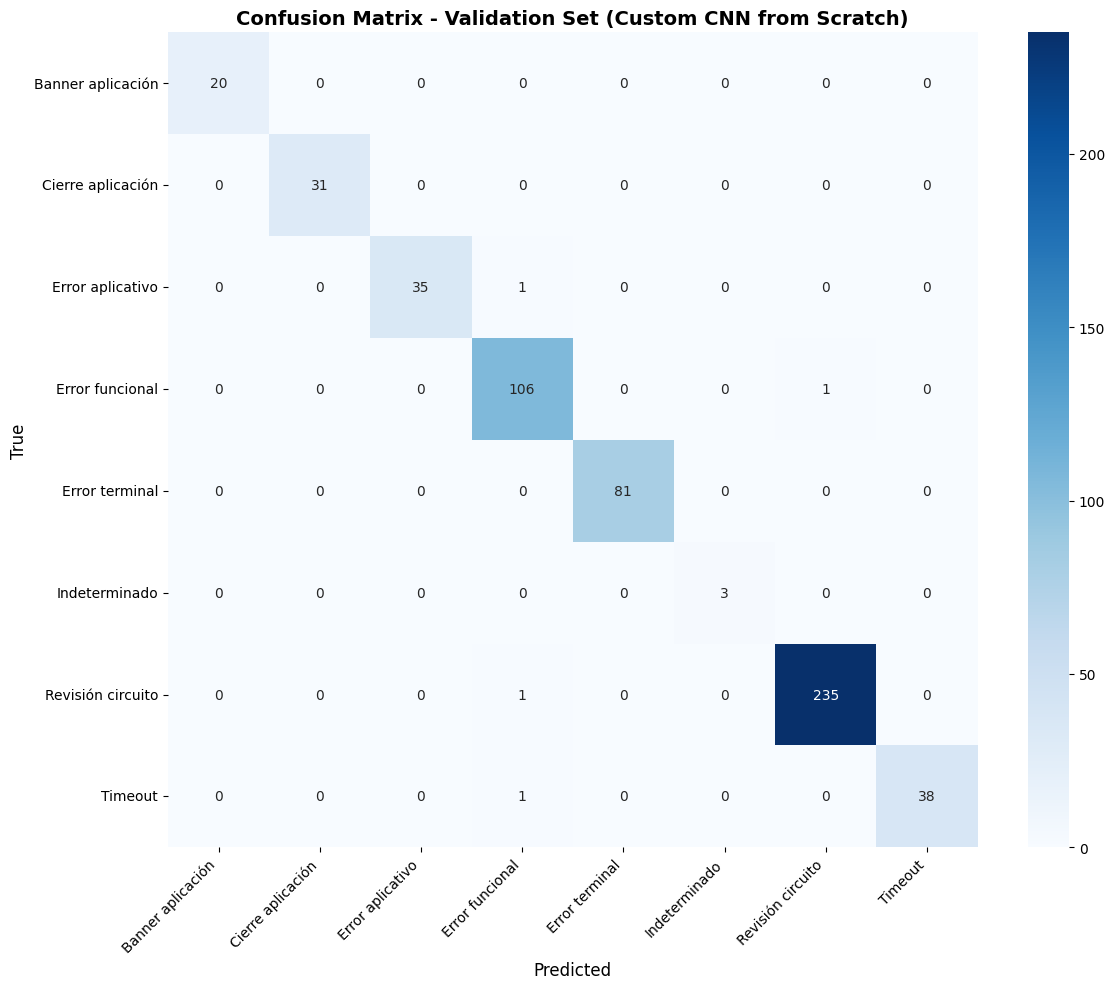

In [58]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Confusion Matrix - Validation Set (Custom CNN from Scratch)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:
# Classification Report
print("Classification Report:")
print("=" * 70)
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Classification Report:
                   precision    recall  f1-score   support

Banner aplicación       1.00      1.00      1.00        20
Cierre aplicación       1.00      1.00      1.00        31
 Error aplicativo       1.00      0.97      0.99        36
  Error funcional       0.97      0.99      0.98       107
   Error terminal       1.00      1.00      1.00        81
    Indeterminado       1.00      1.00      1.00         3
Revisión circuito       1.00      1.00      1.00       236
          Timeout       1.00      0.97      0.99        39

         accuracy                           0.99       553
        macro avg       1.00      0.99      0.99       553
     weighted avg       0.99      0.99      0.99       553



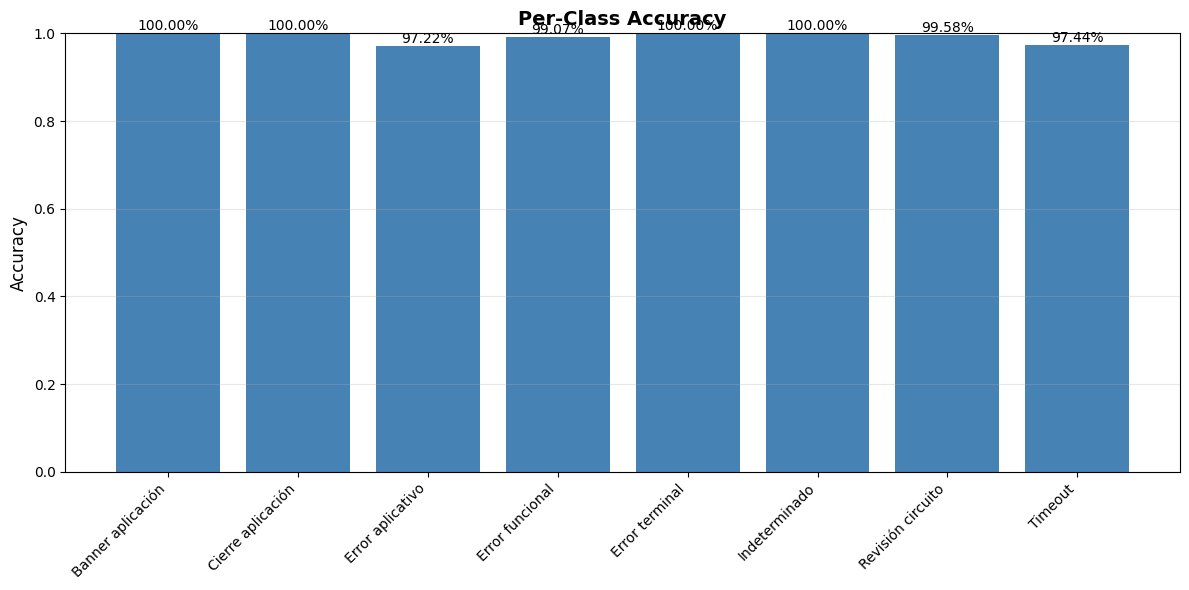


Per-Class Accuracy:
Banner aplicación: 100.00%
Cierre aplicación: 100.00%
Error aplicativo: 97.22%
Error funcional: 99.07%
Error terminal: 100.00%
Indeterminado: 100.00%
Revisión circuito: 99.58%
Timeout: 97.44%


In [60]:
# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(range(len(class_names)), per_class_acc, color='steelblue')
ax.set_xticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Per-Class Accuracy', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, per_class_acc):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\nPer-Class Accuracy:")
for class_name, acc in zip(class_names, per_class_acc):
    print(f"{class_name}: {acc:.2%}")

## 7. Save Model

In [61]:
# Save model weights
model_save_path = r"C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\custom_cnn_from_scratch_DA.pth"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

# Save class names for later inference
class_names_path = r"C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\class_names.json"
with open(class_names_path, 'w') as f:
    json.dump(class_names, f, indent=4)
print(f"Class names saved to {class_names_path}")

Model saved to C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\custom_cnn_from_scratch_DA.pth
Class names saved to C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\class_names.json


In [62]:
# Save training history
history_path = r"C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\custom_cnn_training_history.json"
history_to_save = {
    'accuracy': [float(acc) for acc in history['accuracy']],
    'val_accuracy': [float(acc) for acc in history['val_accuracy']],
    'loss': [float(loss) for loss in history['loss']],
    'val_loss': [float(loss) for loss in history['val_loss']],
}

with open(history_path, 'w') as f:
    json.dump(history_to_save, f, indent=4)
print(f"Training history saved to {history_path}")

Training history saved to C:\Users\Lenovo\Desktop\UB\TFM\TFM\Models\custom_cnn_training_history.json


## 8. Model Inference Example

In [63]:
# Function for single image inference
def predict_image(image_path, model, transform, device, class_names, confidence_threshold=CONFIDENCE_THRESHOLD):
    from PIL import Image
    
    model.eval()
    image = Image.open(image_path).convert('RGB')
    
    # Apply transforms
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        logits = model(image_tensor)
        probabilities = torch.softmax(logits, dim=1)
        max_probability, predicted_class = torch.max(probabilities, dim=1)
        confidence = max_probability.item()
        predicted_class = predicted_class.item()
    
    if confidence < confidence_threshold:
        predicted_label = "uncertain"
    else:
        predicted_label = class_names[predicted_class]
    
    return {
        'predicted_class': predicted_label,
        'confidence': confidence,
        'all_probabilities': {class_names[i]: prob.item() for i, prob in enumerate(probabilities[0])}
    }

print("Inference function defined. Ready to predict on new images.")

Inference function defined. Ready to predict on new images.


In [64]:
# Example inference on a validation image
from PIL import Image

# Get first image from validation set
val_image, val_label = val_dataset[0]

# Get prediction
model.eval()
with torch.no_grad():
    val_image_tensor = val_image.unsqueeze(0).to(device)
    logits = model(val_image_tensor)
    probabilities = torch.softmax(logits, dim=1)
    predicted_class_idx = torch.argmax(probabilities, dim=1).item()

predicted_class = class_names[predicted_class_idx]
true_class = class_names[val_label]
confidence = probabilities[0][predicted_class_idx].item()

print(f"True class: {true_class}")
print(f"Predicted class: {predicted_class}")
print(f"Confidence: {confidence:.4f}")
print(f"\nAll class probabilities:")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {probabilities[0][i].item():.4f}")

True class: Revisión circuito
Predicted class: Revisión circuito
Confidence: 0.8073

All class probabilities:
  Banner aplicación: 0.0361
  Cierre aplicación: 0.0213
  Error aplicativo: 0.0273
  Error funcional: 0.0198
  Error terminal: 0.0120
  Indeterminado: 0.0597
  Revisión circuito: 0.8073
  Timeout: 0.0164


## 9. Model Summary and Comparison

In [65]:
# Create a summary report
print("\n" + "="*70)
print("CUSTOM CNN FROM SCRATCH - MODEL SUMMARY")
print("="*70)

metrics = globals().get('validation_metrics', {})
per_class_df = globals().get('per_class_metrics_df')
history = globals().get('history', {'loss': []})

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel Configuration:")
print(f"  - Architecture: Custom 4-layer CNN")
print(f"  - Total Parameters: {total_params:,}")
print(f"  - Trainable Parameters: {trainable_params:,}")
print(f"  - Training Strategy: From scratch (no pre-trained weights)")

print(f"\nData Configuration:")
print(f"  - Image Size: {IMAGE_SIZE}")
print(f"  - Batch Size: {BATCH_SIZE}")
print(f"  - Training Samples: {len(train_dataset)}")
print(f"  - Validation Samples: {len(val_dataset)}")
print(f"  - Number of Classes: {num_classes}")
print(f"  - Classes: {', '.join(class_names)}")

print(f"\nTraining Configuration:")
print(f"  - Optimizer: AdamW (lr=3e-4)")
print(f"  - Loss Function: Weighted CrossEntropyLoss with label smoothing")
print(f"  - Max Epochs: {EPOCHS}")
print(f"  - Early Stopping Patience: {PATIENCE}")
print(f"  - Confidence Threshold: {CONFIDENCE_THRESHOLD:.2f}")
print(f"  - Epochs Trained: {len(history['loss'])}")
print("  - Oversampling: disabled")

print(f"\nFairness-Oriented Validation Metrics:")
print(f"  - Accuracy: {metrics.get('accuracy', float('nan')):.4f}")
print(f"  - Balanced Accuracy: {metrics.get('balanced_accuracy', float('nan')):.4f}")
print(f"  - Macro Precision: {metrics.get('macro_precision', float('nan')):.4f}")
print(f"  - Macro Recall: {metrics.get('macro_recall', float('nan')):.4f}")
print(f"  - Macro F1: {metrics.get('macro_f1', float('nan')):.4f}")
print(f"  - Weighted F1: {metrics.get('weighted_f1', float('nan')):.4f}")
print(f"  - Worst Class F1: {metrics.get('worst_class_f1', float('nan')):.4f}")
print(f"  - F1 Gap: {metrics.get('f1_gap', float('nan')):.4f}")
print(f"  - Recall Gap: {metrics.get('recall_gap', float('nan')):.4f}")
print(f"  - Uncertainty Rate: {metrics.get('uncertainty_rate', float('nan')):.2%}")

print(f"\nPer-Class Performance (on validation set):")
if per_class_df is not None:
    for class_name in class_names:
        if class_name in per_class_df.index:
            print(f"  - {class_name}: F1={per_class_df.loc[class_name, 'f1-score']:.2%}, Recall={per_class_df.loc[class_name, 'recall']:.2%}")
else:
    print("  - Per-class metrics unavailable until the validation cell runs.")

print("\n" + "="*70)


CUSTOM CNN FROM SCRATCH - MODEL SUMMARY

Model Configuration:
  - Architecture: Custom 4-layer CNN
  - Total Parameters: 1,273,896
  - Trainable Parameters: 1,273,896
  - Training Strategy: From scratch (no pre-trained weights)

Data Configuration:
  - Image Size: (224, 224)
  - Batch Size: 32
  - Training Samples: 2211
  - Validation Samples: 553
  - Number of Classes: 8
  - Classes: Banner aplicación, Cierre aplicación, Error aplicativo, Error funcional, Error terminal, Indeterminado, Revisión circuito, Timeout

Training Configuration:
  - Optimizer: AdamW (lr=3e-4)
  - Loss Function: Weighted CrossEntropyLoss with label smoothing
  - Max Epochs: 30
  - Early Stopping Patience: 7
  - Confidence Threshold: 0.70
  - Epochs Trained: 30
  - Oversampling: disabled

Fairness-Oriented Validation Metrics:
  - Accuracy: 0.9928
  - Balanced Accuracy: 0.9916
  - Macro Precision: 0.9960
  - Macro Recall: 0.9916
  - Macro F1: 0.9938
  - Weighted F1: 0.9928
  - Worst Class F1: 0.9815
  - F1 Gap: 